## Setup — reload data from build_panel_data.ipynb

Run `build_panel_data.ipynb` first to produce the output CSVs. This notebook loads the final panel and re-loads the raw GSDB and IMF DOT files needed to build the bilateral trade matrix and sanction indicators.

In [113]:
import numpy as np
import sys
import pathlib
import pandas as pd
import matplotlib.pyplot as plt

_REPO = pathlib.Path("..").resolve()

def raw(subdir):
    return _REPO / "data" / "raw" / subdir

def processed():
    return _REPO / "data" / "processed"

def panel_cache():
    return _REPO / ".panel_cache"

ANALYSIS_START       = 1960
ANALYSIS_END         = 2023
SANCTIONS_FILL_START = 1950
SANCTIONS_FILL_END   = 2023
MIN_PATENTS          = 10
LOOKBACK_WINDOW      = 10

PATENTS_FRAC      = "pf_inv_ctry_year_frac.csv"
PATENTS_Y02       = "pf_inv_ctry_year_frac_any_y.csv"
PATENTS_DIRTY     = "pf_inv_ctry_year_frac_dirty_innovation.csv"
GSDB_DTA          = "GSDB_V4_dyadic.dta"
GSDB_CSV          = "GSDB_V4.csv"
IMF_DOT           = "IMF_DOT_TXG_FOB_USD.csv"
COUNTRY_CODES     = "country.csv"
UNSD_METHODOLOGY  = "UNSD — Methodology.csv"

IMF_SKIP_COUNTRIES  = ["EMU", "WLD", "EUU", "AFR", "SSF"]
IMF_MANUAL_CODE_MAP = {726: "SOM", 546: "MAC", 314: "ABW", 836: "NRU"}
DROP_ISO3           = {"CSK", "YUG", "SVU", "VDR", "DDR", "PSE", "TWN", "SSD", "GNB", "RHO"}

In [ ]:
sys.path.insert(0, str(pathlib.Path().resolve().parent / "src"))
from sanctions_innovations import (
    SENDERS,
    make_sanction_panel, load_gsdb_data,
    wb_iso3_map, clean_imf_dot, build_bilateral, build_bilateral_eu_one,
    build_sanction_indicators,
    compute_trade_share_weighted, compute_trade_share_weighted_eu_one,
    compute_multi_window, compute_directional,
    compute_gdp_normalised_nominal,
    compute_combined_dir_total, compute_combined_dir_total_full_only,
    compute_episode_combined_dir_total_eu_one,
)

path = str(raw("sanctions") / GSDB_DTA)

In [80]:
final_panel_with_patents_sanctions = pd.read_csv(
    str(processed() / 'final_panel_with_y_02_patents_sanctions_final.csv'),
    index_col=['iso3', 'year'],
)


Import the sanction intensity indices

In [81]:
sanctions, gsdb_cases = load_gsdb_data(
    str(raw("sanctions") / GSDB_DTA),
    str(raw("sanctions") / GSDB_CSV),
)
sanctions_og = sanctions.copy()
sanctions = make_sanction_panel(sanctions, senders=SENDERS).sort_index()
sanctions.index.names = ['iso3', 'year']


In [82]:
IMF_DOT_CSV = str(raw("trade") / IMF_DOT)
imf_dot_df = pd.read_csv(IMF_DOT_CSV)
name = wb_iso3_map()
code_to_iso3 = pd.read_csv(str(raw("reference") / COUNTRY_CODES)).set_index('WEO').ISO.to_dict()
code_to_iso3 |= IMF_MANUAL_CODE_MAP

imf_dot_df_red = clean_imf_dot(
    imf_dot_df,
    name_to_iso3=name,
    code_to_iso3=code_to_iso3,
    skip_countries=IMF_SKIP_COUNTRIES,
)



## Trade-Weighted Sanction Intensity Index

$$
\text{SanctionIntensity}_{ct} = \sum_{i \in \mathcal{S}_{ct}} \text{TradeShare}^{\text{pre}}_{ci,t} \cdot \text{TradeSanction}_{ict}
$$

- $\mathcal{S}_{ct}$: countries imposing a **trade** sanction on $c$ in year $t$  
- $\text{TradeSanction}_{ict} \in \{0,1\}$: 1 if sender $i$ imposes any trade sanction on $c$ in year $t$  
- $\text{TradeShare}^{\text{pre}}_{ci,t}$: rolling 10-year average share of partner $i$ in $c$'s **total trade** (exports + imports) over years $t{-}10$ to $t{-}1$, using IMF DOT bilateral data  
- **UN sanctions omitted** — no meaningful bilateral trade relationship with the UN as an entity; UN-coded senders are naturally excluded after ISO3 conversion in GSDB

 Bilateral trade + rolling pre-period shares:
  - Mirrors imf_dot_df_red to get both directions of trade for each (c, i) pair
  - Pivots to a (c, i) × year matrix, then uses a vectorized .rolling(10).sum().shift(1) to compute sums over
  t-10 to t-1 for both bilateral and total-c trade
  - Divides to get pre_trade_share, clipped to [0, 1]

In [83]:
bilateral = build_bilateral(imf_dot_df_red)

In [84]:
dyadic_sanctions_og = sanctions_og[
    sanctions_og['sanctioning_state_iso3'].notna() &
    (sanctions_og['sanctioning_state_iso3'] != '')
]

sanction_indicator, sanction_indicator_eu_one, import_sanction_indicator, export_sanction_indicator = build_sanction_indicators(dyadic_sanctions_og)
bilateral_eu_one = build_bilateral_eu_one(bilateral)

## Index 1: Trade-Share Weighted Sanction Intensity (EU-Expanded)

**Equation:**
$$\text{SanctionIntensity}_{ct} = \sum_{i \in S(c,t)} \text{TradeShare}^{\text{pre}}_{ci,t}$$

where $\text{TradeShare}^{\text{pre}}_{ci,t}$ is the share of $c$'s bilateral trade with sender $i$ in $c$'s total trade, computed as a rolling sum over the **10 years** prior to $t$ (shift=1). Computed separately for export, import, and total trade volumes.

**Sanction indicator:** any active trade sanction (`trade == 1`) in GSDB CSV. EU sanctions are **expanded to all individual EU member states**.

**Trade data:** IMF Direction of Trade Statistics.

**Output columns:** `sanction_intensity_{export,import,trade}_volume_10`

In [85]:
lookback_window = 10

final_panel_with_patents_sanctions = compute_trade_share_weighted(
    final_panel_with_patents_sanctions, bilateral, sanction_indicator, lookback_window
)

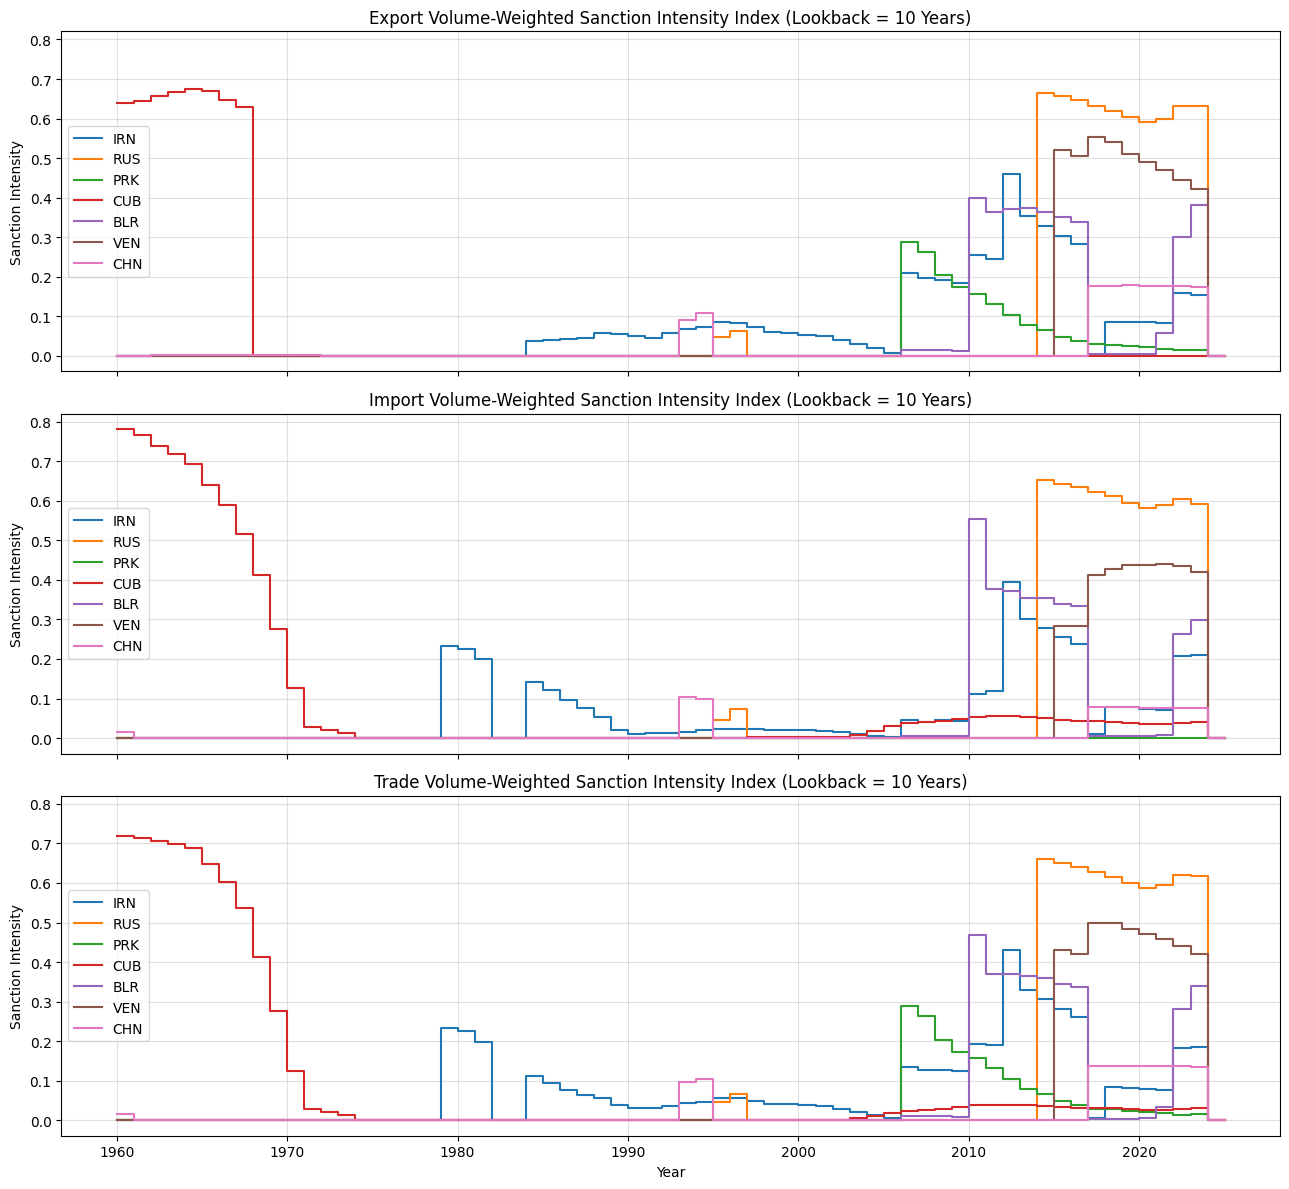

In [86]:


volume_labels = {'export_volume': 'Export Volume', 'import_volume': 'Import Volume', 'trade_volume': 'Trade Volume'}
countries = ['IRN', 'RUS', 'PRK', 'CUB', 'BLR', 'VEN', 'CHN']
fig, ax = plt.subplots(3,1,figsize=(13, 12), sharey=True, sharex=True)
for i, volume_col in enumerate(['export_volume', 'import_volume', 'trade_volume']):
    for c in countries:
        if c in final_panel_with_patents_sanctions.index.get_level_values('iso3'):
            (
                final_panel_with_patents_sanctions.loc[c, f'sanction_intensity_{volume_col}_{lookback_window}']
                .sort_index()
                .plot(label=c, ax=ax[i], drawstyle='steps-post')
            )

    ax[i].set_title(f'{volume_labels[volume_col]}-Weighted Sanction Intensity Index (Lookback = {lookback_window} Years)')
    ax[i].set_ylabel('Sanction Intensity')
    ax[i].set_xlabel('Year')
    ax[i].legend()
    ax[i].grid(True, alpha=0.4)
    plt.tight_layout()

## Index 1b: Trade-Share Weighted Sanction Intensity (EU-as-One Variation)

Same formula as Index 1, with one structural difference:

- All EU member states' trade flows are **aggregated into a single 'EU' node** before computing shares
- EU sanctions are attributed to the 'EU' entity rather than expanded to individual members

This tests sensitivity to the treatment of the EU sender: does disaggregating EU sanctions to member states matter?

**Output columns:** `sanction_intensity_{export,import,trade}_volume_10_eu_as_one`

In [87]:
final_panel_with_patents_sanctions = compute_trade_share_weighted_eu_one(
    final_panel_with_patents_sanctions, bilateral_eu_one, sanction_indicator_eu_one, lookback_window
)

In [88]:
countries = ['IRN', 'RUS', 'PRK', 'CUB', 'BLR', 'VEN', 'CHN']
cmap = plt.get_cmap('tab10')
c_colors = {c: cmap(i) for i, c in enumerate(countries)}

In [89]:
def plot_index_col(panel, col, title, ylabel='Sanction Intensity', countries=countries, c_colors=c_colors, ax=None, figsize=(12, 5), legend=True):
    if ax is None:
        plt.figure(figsize=figsize)
    else:
        plt.sca(ax)
    for c in countries:
        if c in panel.index.get_level_values('iso3'):
            (
                panel.loc[c, col]
                .sort_index()
                .plot(label=c, drawstyle='steps-post', color=c_colors[c])
            )
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('Year')
    if legend:
        plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()

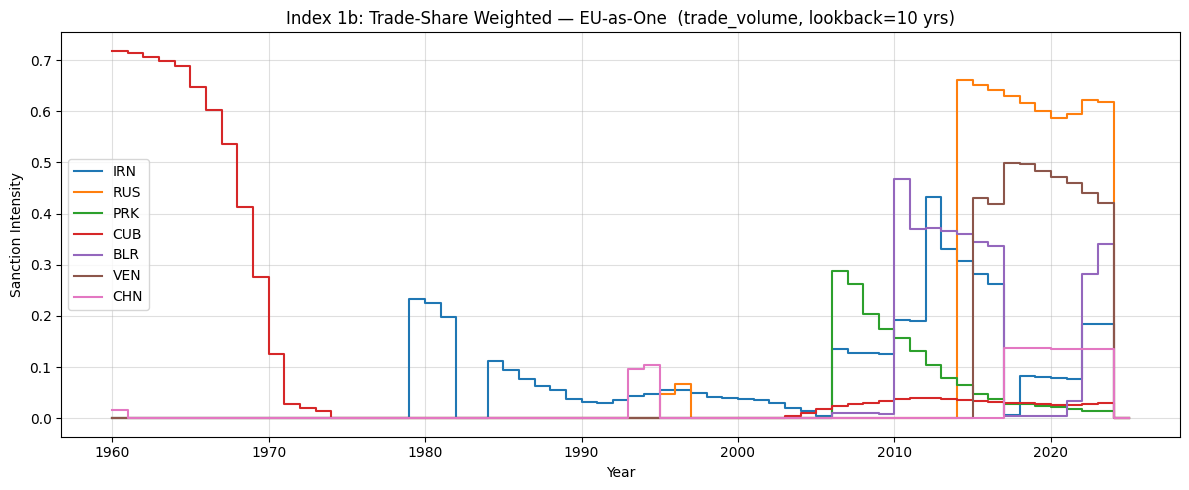

In [90]:

col = f'sanction_intensity_trade_volume_{lookback_window}_eu_as_one'
plot_index_col(panel=final_panel_with_patents_sanctions, col=col, title=f'Index 1b: Trade-Share Weighted — EU-as-One  (trade_volume, lookback={lookback_window} yrs)', ylabel='Sanction Intensity')


## Multiple Lookback Windows (5 / 10 / 15 / 20 Years)

Extends Indices 1 and 2 by computing the same trade-share weighted intensity for additional pre-period lookback windows: **5, 15, and 20 years** (10 years already computed above).

Longer windows smooth out trade-flow volatility and structural breaks; shorter windows are more sensitive to recent shifts in trade relationships.

Computed for both **EU-expanded** and **EU-as-one** variants × all three volume types.

**Output columns (18 new):** `sanction_intensity_{export,import,trade}_volume_{5,15,20}[_eu_as_one]`

In [91]:
final_panel_with_patents_sanctions = compute_multi_window(
    final_panel_with_patents_sanctions, bilateral, bilateral_eu_one,
    sanction_indicator, sanction_indicator_eu_one, windows=(5, 15, 20)
)

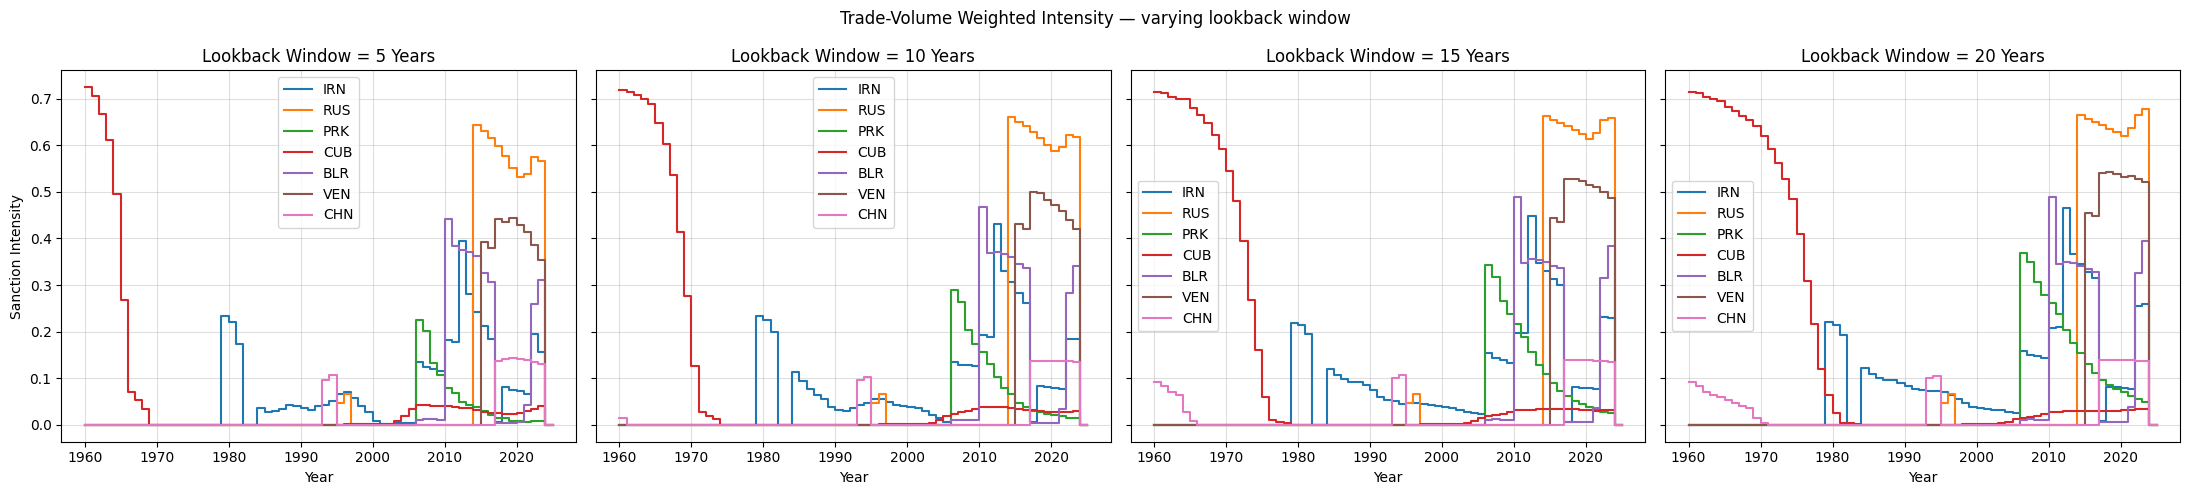

In [92]:
# trade_volume — all 4 windows side by side
windows  = [5, 10, 15, 20]
panel    = final_panel_with_patents_sanctions

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True, sharex=True)
fig.suptitle('Trade-Volume Weighted Intensity — varying lookback window', fontsize=12)

for ax, win in zip(axes, windows):
    col = f'sanction_intensity_trade_volume_{win}'
    plot_index_col(panel, col, title=f'Lookback Window = {win} Years', ax=ax)

## Sanction Intensity: Exports-Only and Imports-Only Trade Shares

Two robustness variants using unidirectional trade flows instead of total bilateral trade:

| Variant | $\text{TradeShare}^{\text{pre}}_{ci,t}$ |
|---|---|
| **Exports** | $c$'s exports to $i$ / $c$'s total exports, avg over $t{-}10$ to $t{-}1$ |
| **Imports** | $c$'s imports from $i$ / $c$'s total imports, avg over $t{-}10$ to $t{-}1$ |

$c$'s imports from $i$ = $i$'s exports to $c$ (mirrored from the same IMF DOT file).  
Sanction sender list identical to v1 (all individual country senders, UN excluded).

## GDP-Normalised Directional Trade-Weighted Sanction Intensity (Nominal GDP)

Identical to Index 3, except the denominator uses **nominal GDP in current USD** (WDI `NY.GDP.MKTP.CD`) instead of constant 2015 USD.

**Equation:**

$$\text{SanctionIntensity}^{\text{GDP-nom}}_{ct} = \frac{\displaystyle\sum_{i \in S(c,t)} \left[ M^{\text{pre}}_{ci} \cdot \text{ExportSanction}_{ict} + X^{\text{pre}}_{ci} \cdot \text{ImportSanction}_{ict} \right]}{\overline{GDP}^{\text{nom,pre}}_c}$$

where $\overline{GDP}^{\text{nom,pre}}_c = \frac{1}{w}\sum_{s=t-w}^{t-1} GDP^{\text{nom}}_{c,s}$ is the rolling $w$-year pre-period mean of $c$'s **nominal GDP in current USD**.

**Directional logic:**
- *Export sanction* by $i$ → $i$ restricts exports *to* $c$ → $c$ loses **imports** from $i$ → weighted by $M^{\text{pre}}_{ci}$ ($c$'s imports from $i$)
- *Import sanction* by $i$ → $i$ restricts imports *from* $c$ → $c$ loses **exports** to $i$ → weighted by $X^{\text{pre}}_{ci}$ ($c$'s exports to $i$)

**Data:** GSDB `descr_trade` (split by direction); IMF DOT bilateral flows; World Bank WDI `NY.GDP.MKTP.CD`.

**Output column:** `sanction_intensity_gdp_nominal`

In [93]:
final_panel_with_patents_sanctions = compute_gdp_normalised_nominal(
    final_panel_with_patents_sanctions, bilateral,
    import_sanction_indicator, export_sanction_indicator, window=lookback_window
)


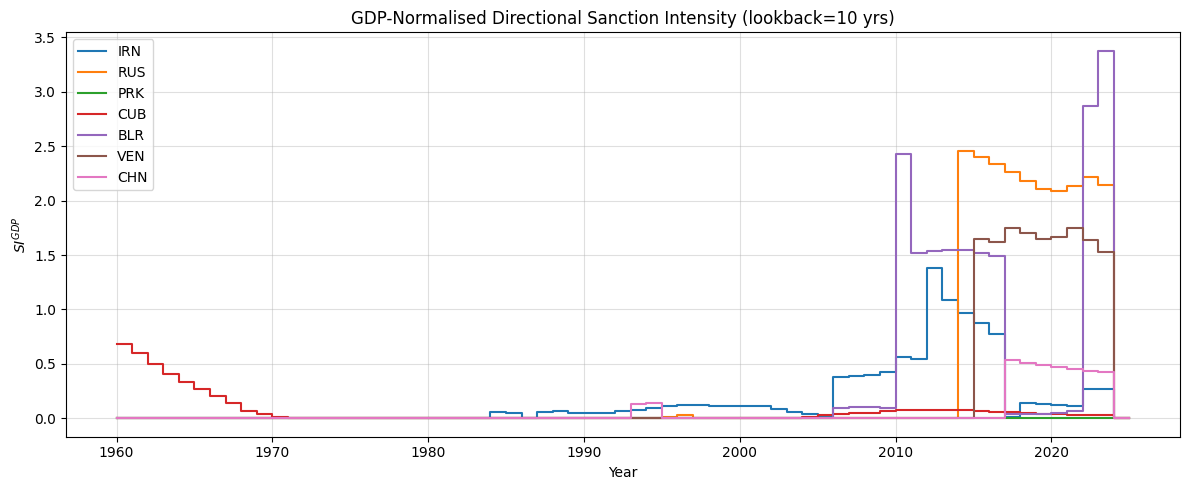

In [94]:
col = 'sanction_intensity_gdp_nominal'
plot_index_col(
    panel=final_panel_with_patents_sanctions, col=col, title=f'GDP-Normalised Directional Sanction Intensity (lookback={lookback_window} yrs)',
    ylabel='$SI^{GDP}$'
    )

## Directional Trade-Share Weighted Sanction Intensity (Sanctioned Country Perspective)

Two complementary indices, each matching the **direction of the trade flow disrupted** to the trade share that weights it:

**Export disruption** (`sanction_intensity_sanctioned_country_exports`):
$$\text{SanctionIntensity}^{\text{exp}}_{ct} = \sum_{i \in S^{\text{imp}}(c,t)} \text{ExportShare}^{\text{pre}}_{ci} \cdot \text{ImportSanction}_{ict}$$
- $\text{ImportSanction}_{ict} = 1$ if sender $i$ restricts **its imports from** $c$ (`imp_compl` or `imp_part`) → $c$ loses export access to market $i$
- $\text{ExportShare}^{\text{pre}}_{ci}$ = $c$'s pre-period exports to $i$ / $c$'s total pre-period exports

**Import disruption** (`sanction_intensity_sanctioned_country_imports`):
$$\text{SanctionIntensity}^{\text{imp}}_{ct} = \sum_{i \in S^{\text{exp}}(c,t)} \text{ImportShare}^{\text{pre}}_{ci} \cdot \text{ExportSanction}_{ict}$$
- $\text{ExportSanction}_{ict} = 1$ if sender $i$ restricts **its exports to** $c$ (`exp_compl` or `exp_part`) → $c$ loses import supply from $i$
- $\text{ImportShare}^{\text{pre}}_{ci}$ = $c$'s pre-period imports from $i$ / $c$'s total pre-period imports

Computed for both **EU-expanded** and **EU-as-one** variants. The plots below overlay both to verify consistency.

**Pre-period window:** rolling 10-year sum, shift=1. **Data:** GSDB `descr_trade`; IMF DOT bilateral flows.

In [95]:
final_panel_with_patents_sanctions = compute_directional(
    final_panel_with_patents_sanctions, bilateral, bilateral_eu_one,
    import_sanction_indicator, export_sanction_indicator, dyadic_sanctions_og, lookback_window
)

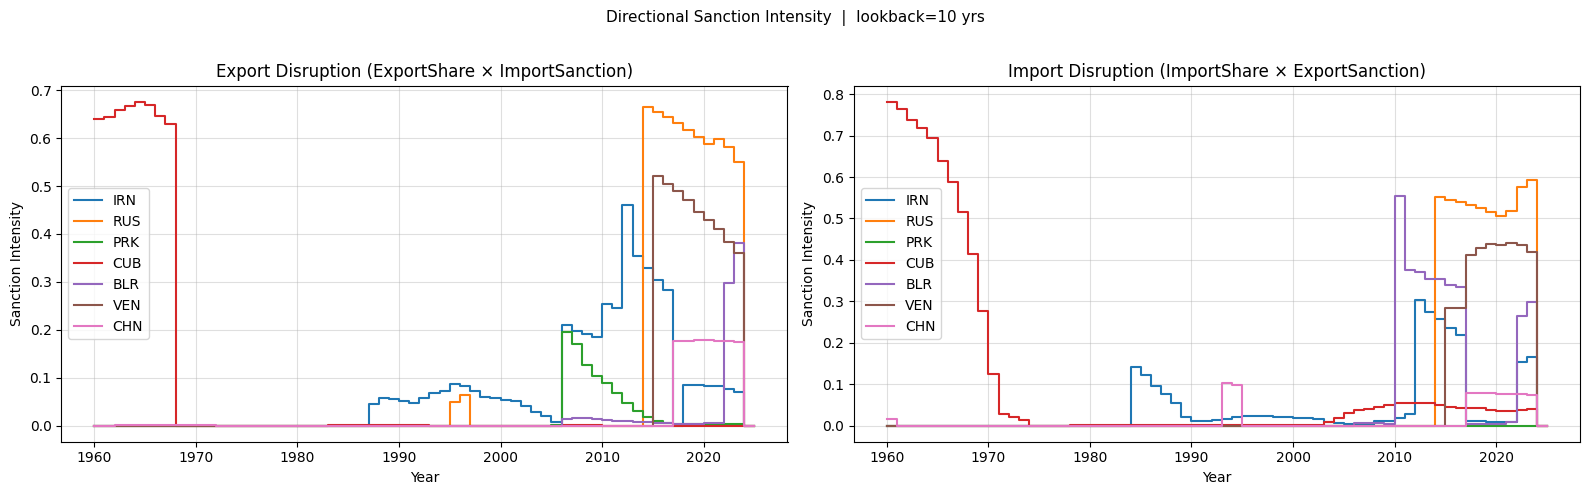

In [96]:
pairs = [
    ('sanction_intensity_sanctioned_country_exports_eu_as_one',
     'Export Disruption (ExportShare × ImportSanction)'),
    ('sanction_intensity_sanctioned_country_imports_eu_as_one',
     'Import Disruption (ImportShare × ExportSanction)'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Directional Sanction Intensity  |  lookback={lookback_window} yrs\n', fontsize=11)

for ax, (col_eu1, title) in zip(axes, pairs):
    plot_index_col(panel=final_panel_with_patents_sanctions, col=col_eu1, title=title, ax=ax, legend=True)

## Combined Directional Trade Sanction Intensity Index — Total-Trade Normalised 

A variant of the Combined Directional Index above, where both the export and import flows in the numerator are divided by **country $c$'s total pre-period trade** (exports + imports with all partners), rather than by directional totals separately.

**Equation:**
$$\text{SanctionIntensity}^{\text{dir-total}}_{ct} = \sum_{i \in S(c,t)} \left[ \frac{X^{\text{pre}}_{ci}}{T^{\text{pre}}_c} \cdot \text{ImportSanction}_{ict} + \frac{M^{\text{pre}}_{ci}}{T^{\text{pre}}_c} \cdot \text{ExportSanction}_{ict} \right]$$

**Where:**
- $X^{\text{pre}}_{ci}$ = rolling pre-period sum of $c$'s exports to $i$
- $M^{\text{pre}}_{ci}$ = rolling pre-period sum of $c$'s imports from $i$
- $T^{\text{pre}}_c = \sum_j (X^{\text{pre}}_{cj} + M^{\text{pre}}_{cj})$ = $c$'s total pre-period trade with all partners
- $\text{ImportSanction}_{ict} = 1$ if $i$ restricts imports from $c$ (`imp_compl`/`imp_part`) → $c$ loses export market in $i$
- $\text{ExportSanction}_{ict} = 1$ if $i$ restricts exports to $c$ (`exp_compl`/`exp_part`) → $c$ loses import supply from $i$

**Key difference from previous version:** Using a single common denominator $T^{\text{pre}}_c$ means the export-disruption and import-disruption terms are on the same scale and directly comparable — a 1% share of total trade lost on the export side equals a 1% share lost on the import side.

Computed for both **EU-expanded** and **EU-as-one** variants.

**Output columns:** `sanction_intensity_combined_dir_total_10`, `sanction_intensity_combined_dir_total_10_eu_as_one`

In [97]:
final_panel_with_patents_sanctions = compute_combined_dir_total(
    final_panel_with_patents_sanctions, bilateral, bilateral_eu_one,
    import_sanction_indicator, export_sanction_indicator, dyadic_sanctions_og, lookback_window
)

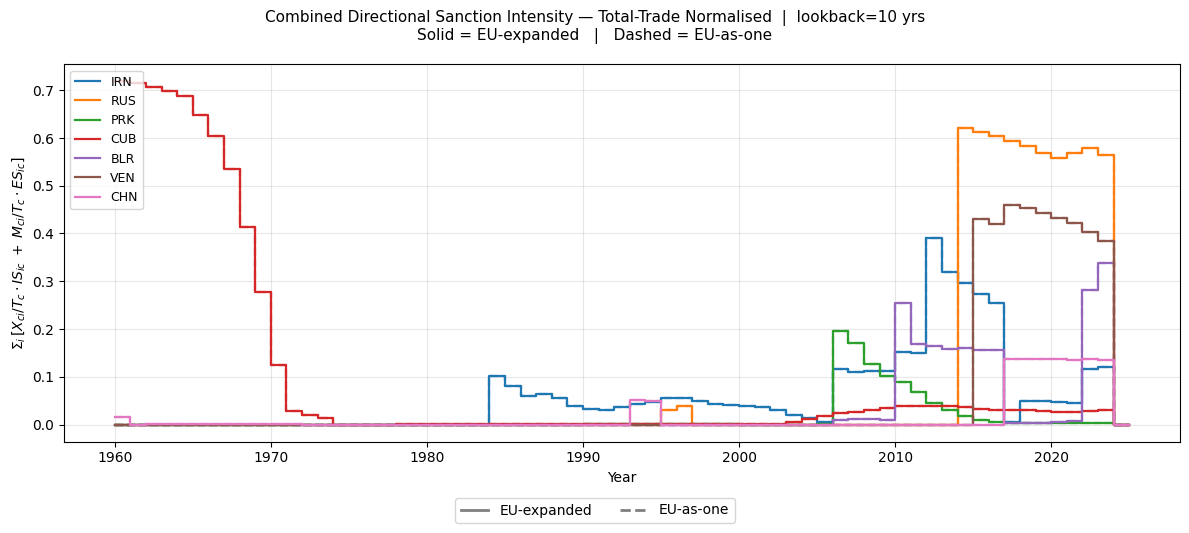

In [98]:
# ── Plot: Combined Directional Total-Trade — EU-expanded vs EU-as-one ────────

import matplotlib.lines as mlines

panel     = final_panel_with_patents_sanctions
_col      = f'sanction_intensity_combined_dir_total_{lookback_window}'
_col_eu1  = f'sanction_intensity_combined_dir_total_{lookback_window}_eu_as_one'

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(
    f'Combined Directional Sanction Intensity — Total-Trade Normalised  |  lookback={lookback_window} yrs\n'
    'Solid = EU-expanded   |   Dashed = EU-as-one',
    fontsize=11
)
for country in countries:
    if country not in panel.index.get_level_values('iso3'):
        continue
    color = c_colors[country]
    s_exp = panel.loc[country, _col].sort_index()
    s_eu1 = panel.loc[country, _col_eu1].sort_index()
    ax.plot(s_exp.index, s_exp.values, color=color, lw=1.6,
            drawstyle='steps-post', label=country)
    ax.plot(s_eu1.index, s_eu1.values, color=color, lw=1.6,
            drawstyle='steps-post', linestyle='--')

ax.set_xlabel('Year')
ax.set_ylabel(r'$\Sigma_i\,[X_{ci}/T_c \cdot IS_{ic}\;+\;M_{ci}/T_c \cdot ES_{ic}]$')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
solid_l = mlines.Line2D([], [], color='grey', lw=2, label='EU-expanded')
dash_l  = mlines.Line2D([], [], color='grey', lw=2, linestyle='--', label='EU-as-one')
fig.legend(handles=[solid_l, dash_l], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()


In [99]:
final_panel_with_patents_sanctions = compute_combined_dir_total_full_only(
    final_panel_with_patents_sanctions, bilateral, bilateral_eu_one,
    dyadic_sanctions_og, window=lookback_window
)


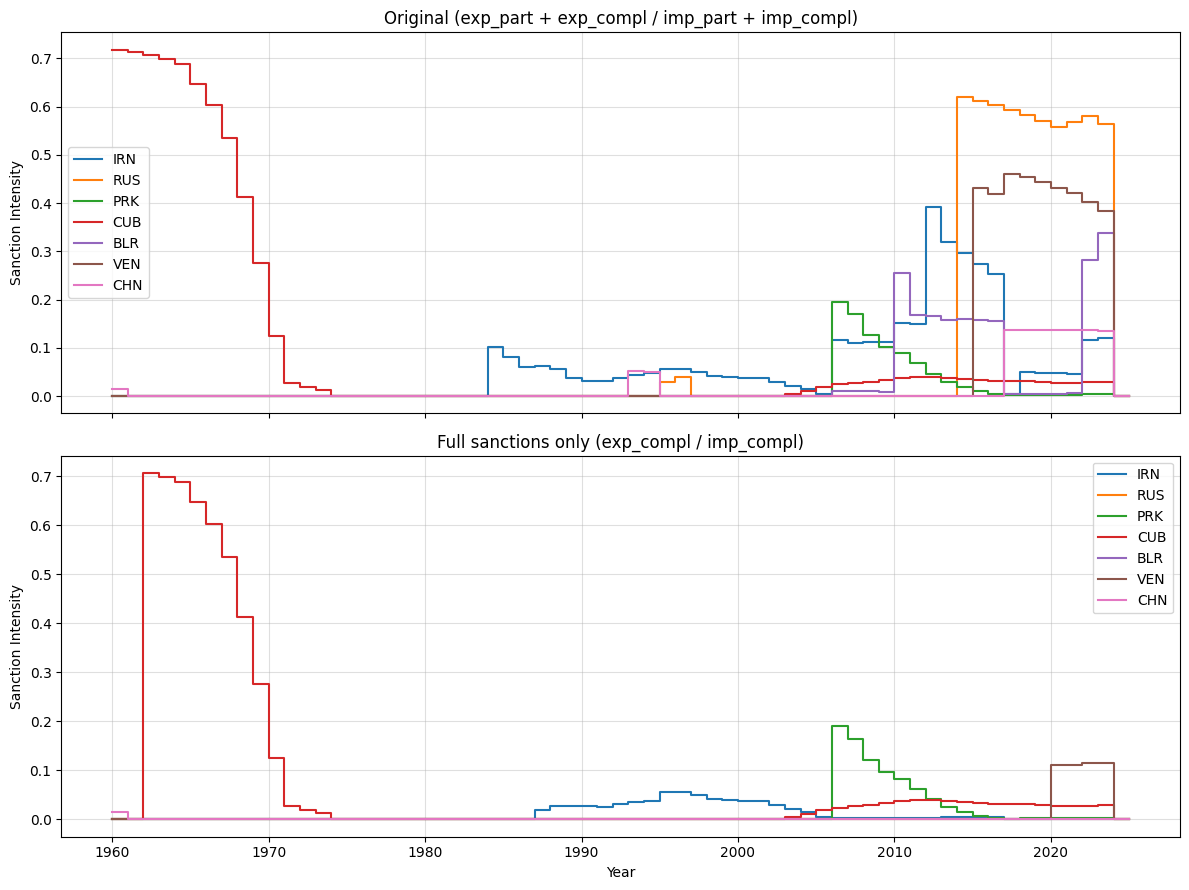

In [100]:
panel      = final_panel_with_patents_sanctions
_col_orig  = f'sanction_intensity_combined_dir_total_{lookback_window}_eu_as_one'
_col_full  = f'sanction_intensity_combined_dir_total_{lookback_window}_eu_as_one_full'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
plot_index_col(panel, _col_orig, title=f'Original (exp_part + exp_compl / imp_part + imp_compl)', ax=ax1)
plot_index_col(panel, _col_full, title=f'Full sanctions only (exp_compl / imp_compl)', ax=ax2)

plt.tight_layout()
plt.show()

In [101]:
final_panel_with_patents_sanctions = compute_episode_combined_dir_total_eu_one(
    final_panel_with_patents_sanctions, bilateral_eu_one, dyadic_sanctions_og
)


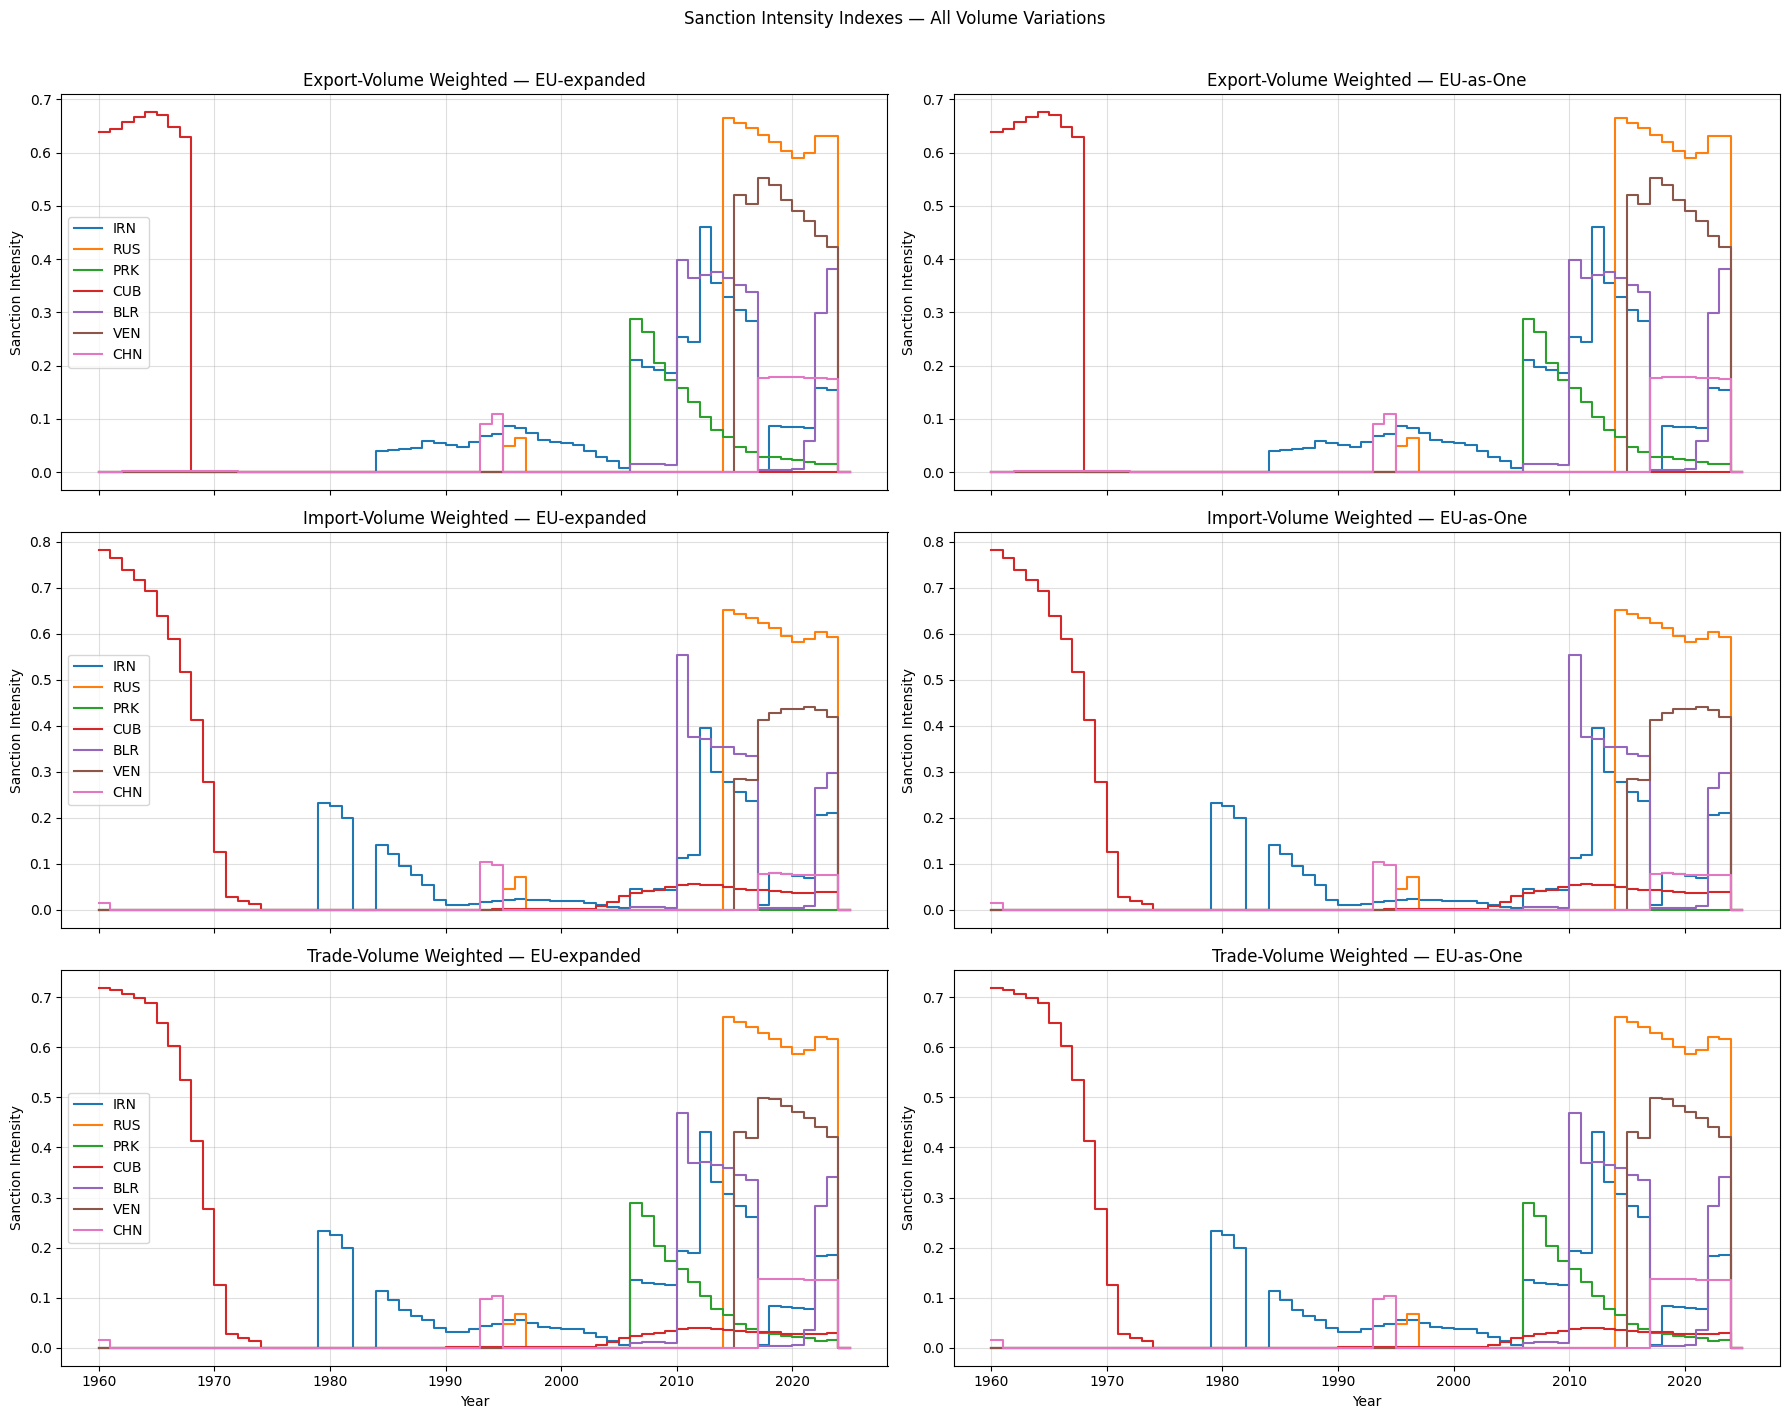

In [102]:
import matplotlib.lines as mlines
vol_types  = ['export_volume', 'import_volume', 'trade_volume']
vol_labels = ['Export-Volume Weighted', 'Import-Volume Weighted', 'Trade-Volume Weighted']


fig, axes = plt.subplots(3, 2, figsize=(18, 14), sharex=True)
fig.suptitle('Sanction Intensity Indexes — All Volume Variations', fontsize=12, y=1.01)
for row, (vol, vlab) in enumerate(zip(vol_types, vol_labels)):
    col_exp = f'sanction_intensity_{vol}_{lookback_window}'
    col_eu  = f'sanction_intensity_{vol}_{lookback_window}_eu_as_one'

    ax_exp = axes[row, 0]
    ax_eu  = axes[row, 1]

    plot_index_col(panel=final_panel_with_patents_sanctions, col=col_exp, title=f'{vlab} — EU-expanded', ax=ax_exp, legend=False)
    plot_index_col(panel=final_panel_with_patents_sanctions, col=col_eu, title=f'{vlab} — EU-as-One', ax=ax_eu, legend=False)
    ax_exp.legend(countries)


In [103]:
# ── Column rename maps ───────────────────────────────────────────────────────
SANCTION_INTENSITY_RENAME = {
    # Trade-share weighted (EU aggregated)
    'sanction_intensity_trade_volume_5_eu_as_one':  'si_tot_w5',
    'sanction_intensity_trade_volume_10_eu_as_one': 'si_tot_w10',
    'sanction_intensity_trade_volume_15_eu_as_one': 'si_tot_w15',

    # GDP-normalised
    'sanction_intensity_gdp':         'si_gdp',
    'sanction_intensity_gdp_nominal': 'si_gdp_nominal',

    # Directional disruption measures
    'sanction_intensity_sanctioned_country_exports_eu_as_one': 'si_xdis',
    'sanction_intensity_sanctioned_country_imports_eu_as_one': 'si_mdis',

    # Combined directional measure
    'sanction_intensity_combined_dir_total_10_eu_as_one':
        'si_dir_tot_trade_normalized',
}

DEPENDENT_VAR_RENAME = {
    'frac_classical_inv':   'total_patents',
    'sum_y02_patents':      'y02_patents',
    'frac_dirty_innovation':'fossil_fuel_patents',
}

# ── Source dataframe ─────────────────────────────────────────────────────────
df = final_panel_with_patents_sanctions

# ── Column groups ────────────────────────────────────────────────────────────
geo_cols = [
    c for c in df.columns
    if any(k in c for k in ('region_name', 'sub_region', 'income_level'))
]

dep_var_cols = [
    c for c in DEPENDENT_VAR_RENAME
    if c in df.columns
]

control_cols = [
    c for c in df.columns
    if any(k in c.lower() for k in ('gdp', 'fdi', 'trade_pct', 'population'))
]

binary_sanction_cols = [
    c for c in df.columns
    if c.startswith('sanctioned_by_') or c.startswith('any_')
]

senders = ('US', 'UN', 'EU', 'BRICS', 'OECD', 'OPEC', 'OTHER')
categories = ('arms', 'military', 'trade', 'financial', 'travel')

sender_category_cols = [
    f'{sender}_{category}'
    for sender in senders
    for category in categories
    if f'{sender}_{category}' in df.columns
]

sanction_intensity_cols = [
    c for c in SANCTION_INTENSITY_RENAME
    if c in df.columns
]

# ── Final column selection ───────────────────────────────────────────────────
selected_cols = list(dict.fromkeys(
    geo_cols
    + dep_var_cols
    + control_cols
    + binary_sanction_cols
    + sender_category_cols
    + sanction_intensity_cols
))

rename_map = {
    **DEPENDENT_VAR_RENAME,
    **SANCTION_INTENSITY_RENAME,
}

panel = (
    df[selected_cols]
    .rename(columns=rename_map)
    .copy()
)


# Coalition indicators

def build_coalition_indicators(us_flag, eu_flag, un_flag):

    us = df[us_flag].eq(1)
    eu = df[eu_flag].eq(1)

    return {
        'unilateral':   ((us | eu) & ~(us & eu)).astype(int),
        'plurilateral': (us & eu).astype(int),
        'multilateral': df[un_flag].eq(1).astype(int),
    }


coalition_specs = {
    '': (
        'sanctioned_by_US',
        'sanctioned_by_EU',
        'sanctioned_by_UN',
    ),
    '_financial': (
        'US_financial',
        'EU_financial',
        'UN_financial',
    ),
    '_trade': (
        'US_trade',
        'EU_trade',
        'UN_trade',
    ),
}

for suffix, (us_col, eu_col, un_col) in coalition_specs.items():

    indicators = build_coalition_indicators(
        us_flag=us_col,
        eu_flag=eu_col,
        un_flag=un_col,
    )

    for coalition_type, values in indicators.items():
        panel[f'{coalition_type}{suffix}'] = values

# Export

export_path = processed() / '150426_panel.csv'
panel.reset_index().to_csv(export_path, index=False)

print(f'\nExported {panel.shape[0]:,} rows × '
      f'{panel.shape[1]} columns → {export_path}')

# panel


Exported 13,398 rows × 64 columns → /Users/jayranenobari/sanctions_innovations/data/processed/150426_panel.csv


In [104]:
_drop_iso3 = {'CSK', 'YUG', 'SVU', 'VDR', 'DDR', 'PSE', 'TWN', 'SSD', 'GNB', 'RHO'}

panel_cleaned = panel[
    ~panel.index.get_level_values('iso3').isin(_drop_iso3)
].copy()

#export panel_cleaned to csv with index
panel_cleaned.reset_index().to_csv(str(processed() / "final_panel.csv"), index=True)

In [105]:
panel_red = panel.loc[panel.index.get_level_values('year').isin(range(1960, 2024))].copy()

In [106]:
_vars = {
    'Total Patents':       'total_patents',
    'Green Patents':       'y02_patents',
    'Fossil Fuel Patents': 'fossil_fuel_patents',
}

def _desc(s):
    n_total = len(s)
    n_nan   = s.isna().sum()
    s = s.dropna()
    n        = len(s)
    n_zero   = (s == 0).sum()
    lost_log = (s <= 0).sum()
    return pd.Series({
        'Observations':                    f'{n:,}',
        'Share of NaN observations (%)':   f'{100 * n_nan / n_total:.2f}',
        'Number of NaNs':                   f'{n_nan:,}',
        'Mean':                            f'{s.mean():.4f}',
        'Median':                          f'{s.median():.4f}',
        'Standard deviation':              f'{s.std():.4f}',
        'Minimum':                         f'{s.min():.4f}',
        'Maximum':                         f'{s.max():.4f}',
        'Share of zero observations (%)':  f'{100 * n_zero / n:.2f}',
        'Number of zeros':                 f'{n_zero:,}',
        'Skewness':                        f'{s.skew():.4f}',
        'Observations lost in log(y) OLS': f'{lost_log:,}',
    })

_stats = pd.concat(
    {label: _desc(panel_red[col]) for label, col in _vars.items()},
    axis=1,
)
_stats.index.name = 'Statistic'
_stats

,Total Patents,Green Patents,Fossil Fuel Patents
Statistic,,,
Observations,"9,784","9,784","7,281"
Share of NaN observations (%),24.69,24.69,43.96
Number of NaNs,"3,208","3,208","5,711"
Mean,6724.2373,592.8421,50.9800
Median,3.0000,0.0000,0.0000
Standard deviation,105900.3286,15588.4899,575.4565
Minimum,0.0000,0.0000,0.0000
Maximum,4198886.7321,980363.1553,20094.7079
Share of zero observations (%),25.33,58.80,61.41


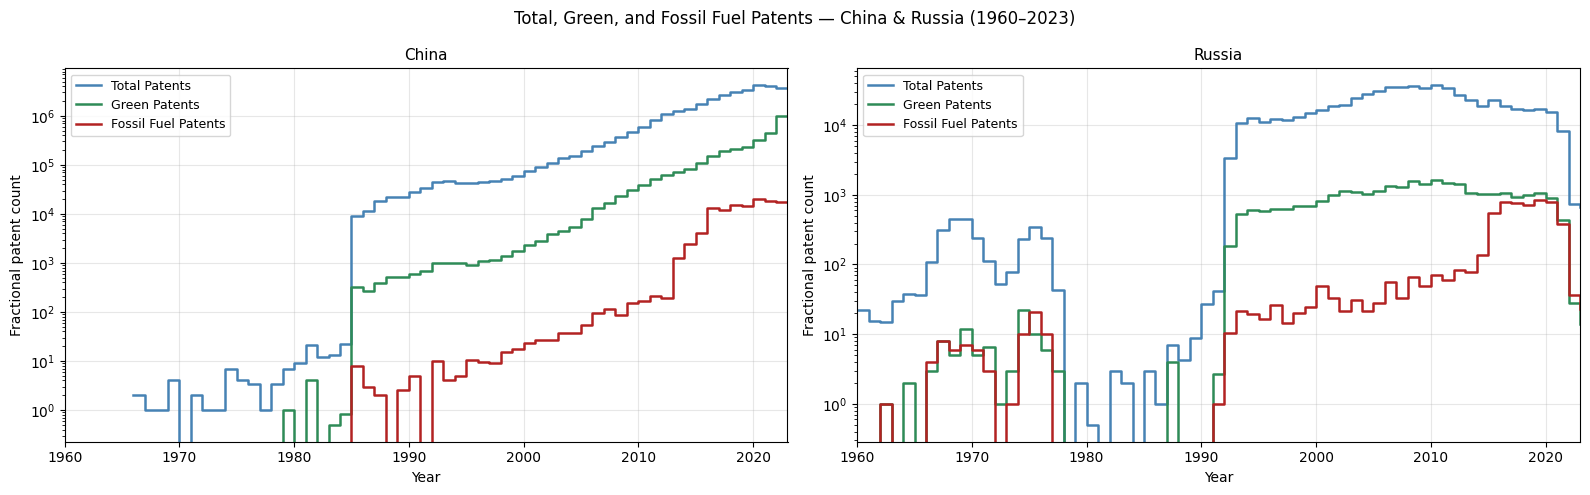

In [107]:
_countries = {'CHN': 'China', 'RUS': 'Russia'}
_pat_cols  = {
    'total_patents':       ('Total Patents',       'steelblue'),
    'y02_patents':         ('Green Patents',        'seagreen'),
    'fossil_fuel_patents': ('Fossil Fuel Patents',  'firebrick'),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, (iso, country) in zip(axes, _countries.items()):
    _sub = panel_red.loc[iso].sort_index()
    for col, (label, color) in _pat_cols.items():
        if col in _sub.columns:
            ax.plot(_sub.index, _sub[col], label=label, color=color,
                    lw=1.8, drawstyle='steps-post')
    ax.set_title(country, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Fractional patent count')
    ax.set_xlim(1960, 2023)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

fig.suptitle('Total, Green, and Fossil Fuel Patents — China & Russia (1960–2023)', fontsize=12)
plt.tight_layout()
plt.show()

In [108]:
_pat_cols = {
    'Total Patents':       'total_patents',
    'Green Patents':       'y02_patents',
    'Fossil Fuel Patents': 'fossil_fuel_patents',
}

rows = []
for region, grp in panel_red.groupby('sub_region_name'):
    row = {'Subregion': region}
    for label, col in _pat_cols.items():
        if col not in grp.columns:
            row[f'{label} — % Zero'] = 'n/a'
            row[f'{label} — % NaN']  = 'n/a'
            continue
        s = grp[col]
        n = len(s)
        row[f'{label} — % Zero'] = f'{100 * (s == 0).sum() / n:.1f}'
        row[f'{label} — % NaN']  = f'{100 * s.isna().sum() / n:.1f}'
    rows.append(row)

_result = pd.DataFrame(rows).set_index('Subregion').sort_index()

_result.columns = pd.MultiIndex.from_tuples(
    [(label, stat)
     for label in _pat_cols
     for stat in ['% Zero', '% NaN']],
    names=['Patent type', 'Statistic'],
)

print('Zero and NaN observations by subregion (1960–2023)\n')
display(_result)

Zero and NaN observations by subregion (1960–2023)



Patent type                     Total Patents       Green Patents        \
Statistic                              % Zero % NaN        % Zero % NaN   
Subregion                                                                 
Australia and New Zealand                 1.6   0.0          14.1   0.0   
Central Asia                              5.0  50.0          22.8  50.0   
Eastern Asia                              8.0  10.0          37.1  10.0   
Eastern Europe                            5.5  12.3          20.9  12.3   
Latin America and the Caribbean          16.9  26.0          52.4  26.0   
Melanesia                                34.4  47.3          51.6  47.3   
Micronesia                               25.3  63.8          35.0  63.8   
Northern Africa                          19.8  16.1          58.6  16.1   
Northern America                         14.1   9.0          32.4   9.0   
Northern Europe                           7.3  16.4          18.2  16.4   
Polynesia                                24.5  51.6          45.3  51.6   
South-eastern Asia                       20.0  18.6          48.3  18.6   
Southern Asia                            30.2  18.4          53.8  18.4   
Southern Europe                           5.8  27.5          34.5  27.5   
Sub-Saharan Africa                       36.7  30.1          61.5  30.1   
Western Asia                             13.1  24.4          41.5  24.4   
Western Europe                            0.3   0.0          10.8   0.0   

Patent type                     Fossil Fuel Patents        
Statistic                                    % Zero % NaN  
Subregion                                                  
Australia and New Zealand                      22.7   1.6  
Central Asia                                   38.1  55.0  
Eastern Asia                                   37.7  18.1  
Eastern Europe                                 35.9  17.8  
Latin America and the Caribbean                44.5  42.9  
Melanesia                                      17.6  81.6  
Micronesia                                     10.9  89.1  
Northern Africa                                49.0  35.9  
Northern America                               26.6  23.0  
Northern Europe                                24.9  23.7  
Polynesia                                      24.0  76.0  
South-eastern Asia                             37.5  38.6  
Southern Asia                                  36.1  48.6  
Southern Europe                                42.1  33.3  
Sub-Saharan Africa                             29.0  67.6  
Western Asia                                   39.2  37.6  
Western Europe                                 18.1   0.3

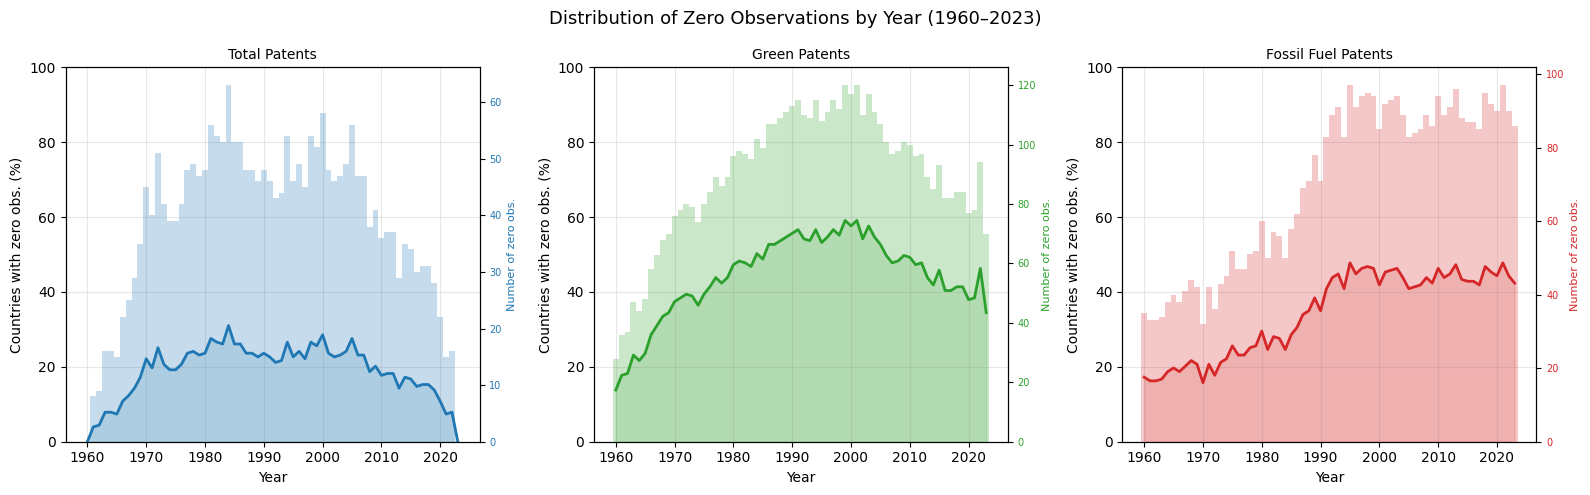

In [109]:
_pat_cols = {
    'Total Patents':       ('total_patents',       '#1f77b4'),
    'Green Patents':       ('y02_patents',         '#2ca02c'),
    'Fossil Fuel Patents': ('fossil_fuel_patents', '#d62728'),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution of Zero Observations by Year (1960–2023)', fontsize=13)

for ax, (label, (col, color)) in zip(axes, _pat_cols.items()):
    if col not in panel_red.columns:
        ax.set_title(f'{label}\n(column not found)')
        continue

    _yr = (
        panel_red.groupby('year')[col]
        .apply(lambda s: 100 * (s == 0).sum() / len(s))
        .reset_index(name='pct_zero')
    )
    _n_zero = panel_red.groupby('year')[col].apply(lambda s: (s == 0).sum()).reset_index(name='n_zero')

    ax.fill_between(_yr['year'], _yr['pct_zero'], alpha=0.15, color=color)
    ax.plot(_yr['year'], _yr['pct_zero'], color=color, lw=2)

    ax2 = ax.twinx()
    ax2.bar(_n_zero['year'], _n_zero['n_zero'], alpha=0.25, color=color, width=1)
    ax2.set_ylabel('Number of zero obs.', fontsize=8, color=color)
    ax2.tick_params(axis='y', labelcolor=color, labelsize=7)

    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Year')
    ax.set_ylabel('Countries with zero obs. (%)')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

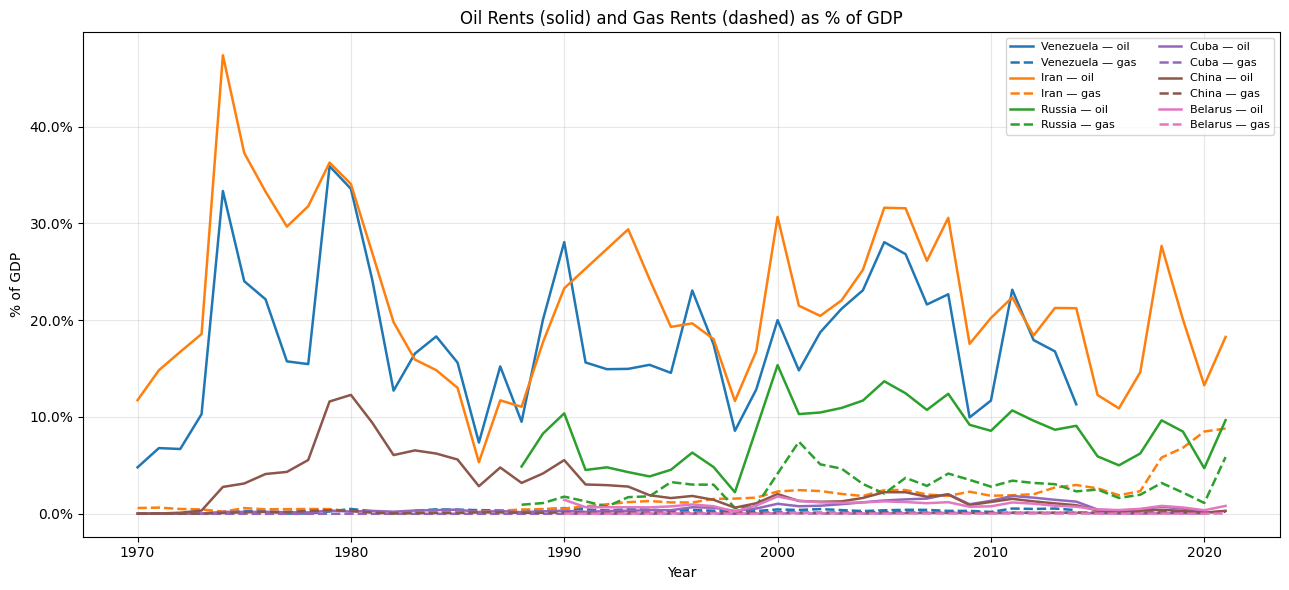

In [110]:

import matplotlib.ticker as mticker

_COUNTRIES = ["VEN", "IRN", "RUS", "PRK", "CUB", "CHN", "BLR"]
_LABELS    = {"VEN": "Venezuela", "IRN": "Iran", "RUS": "Russia",
              "PRK": "North Korea", "CUB": "Cuba", "CHN": "China", "BLR": "Belarus"}

cmap      = plt.get_cmap("tab10")
_c_colors = {c: cmap(i) for i, c in enumerate(_COUNTRIES)}


_src = final_panel_with_patents_sanctions.reset_index()
_df  = _src[_src["iso3"].isin(_COUNTRIES)].copy()

fig, ax = plt.subplots(1, 1, figsize=(13, 6))

# ── Oil & Gas Rents as % of GDP ─────────────────────────────────
for iso3 in _COUNTRIES:
    _s = _df[_df["iso3"] == iso3].sort_values("year")
    color = _c_colors[iso3]
    label = _LABELS[iso3]

    _oil = _s.dropna(subset=["oil_rents_pct_gdp"])
    _gas = _s.dropna(subset=["gas_rents_pct_gdp"])

    if not _oil.empty:
        ax.plot(_oil["year"], _oil["oil_rents_pct_gdp"],
                 color=color, lw=1.8, linestyle="-",  label=f"{label} — oil")
    if not _gas.empty:
        ax.plot(_gas["year"], _gas["gas_rents_pct_gdp"],
                 color=color, lw=1.8, linestyle="--", label=f"{label} — gas")

ax.set_title("Oil Rents (solid) and Gas Rents (dashed) as % of GDP")
ax.set_xlabel("Year")
ax.set_ylabel("% of GDP")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


In [111]:
# ── Fetch V-Dem democracy indices from Our World in Data ─────────────────────
import io, ssl, urllib.request
import requests, urllib3
import pandas as pd

def get_vdem_data():
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    urllib.request.install_opener(urllib.request.build_opener(urllib.request.HTTPSHandler(context=ctx)))
    urllib3.disable_warnings()

    session = requests.Session()
    session.verify = False

    vdem_url = (
        'https://ourworldindata.org/grapher/varieties-democracy-vdem.csv'
        '?v=1&csvType=full&useColumnShortNames=true'
    )
    resp = session.get(vdem_url, headers={'User-Agent': 'Our World In Data data fetch/1.0'})
    resp.raise_for_status()
    df = pd.read_csv(io.StringIO(resp.text))
    print('Removing following entities without ISO3 codes: \n', df[df["code"].isna()]["entity"].unique().tolist())
    return df[df["code"].notna()]
vdem_raw = get_vdem_data()
vdem_raw.to_csv(str(processed() / 'vdem.csv'), index=False)
print(f'Saved vdem.csv  —  {vdem_raw.shape[0]:,} rows, columns: {vdem_raw.columns.tolist()}')

Removing following entities without ISO3 codes: 
 ['Africa (population-weighted)', 'Asia (population-weighted)', 'Brunswick', 'Duchy of Nassau', 'Europe (population-weighted)', 'Hamburg', 'North America (population-weighted)', 'Oceania (population-weighted)', 'Oldenburg', 'Palestine/Gaza', 'Palestine/West Bank', 'Piedmont-Sardinia', 'Saxe-Weimar-Eisenach', 'South America (population-weighted)', 'World (population-weighted)', 'Wurttemberg']
Saved vdem.csv  —  32,314 rows, columns: ['entity', 'code', 'year', 'electdem_vdem__estimate_best', 'libdem_vdem__estimate_best', 'participdem_vdem__estimate_best', 'delibdem_vdem__estimate_best', 'egaldem_vdem__estimate_best']


13,398 rows × 42 columns
Exported → /Users/jayranenobari/sanctions_innovations/data/processed/analysis_panel.csv


,nan_pct,zero_pct,mean,std,min,max
frac_green,45.5%,24.4%,0.0660,0.1485,0.0000,1.0000
frac_fossil,45.7%,33.4%,0.0217,0.0932,0.0000,1.0000
green_of_green_fossil,67.4%,2.1%,0.7978,0.2786,0.0000,1.0000
frac_fossil_of_green_fossil,67.4%,11.2%,0.2022,0.2786,0.0000,1.0000


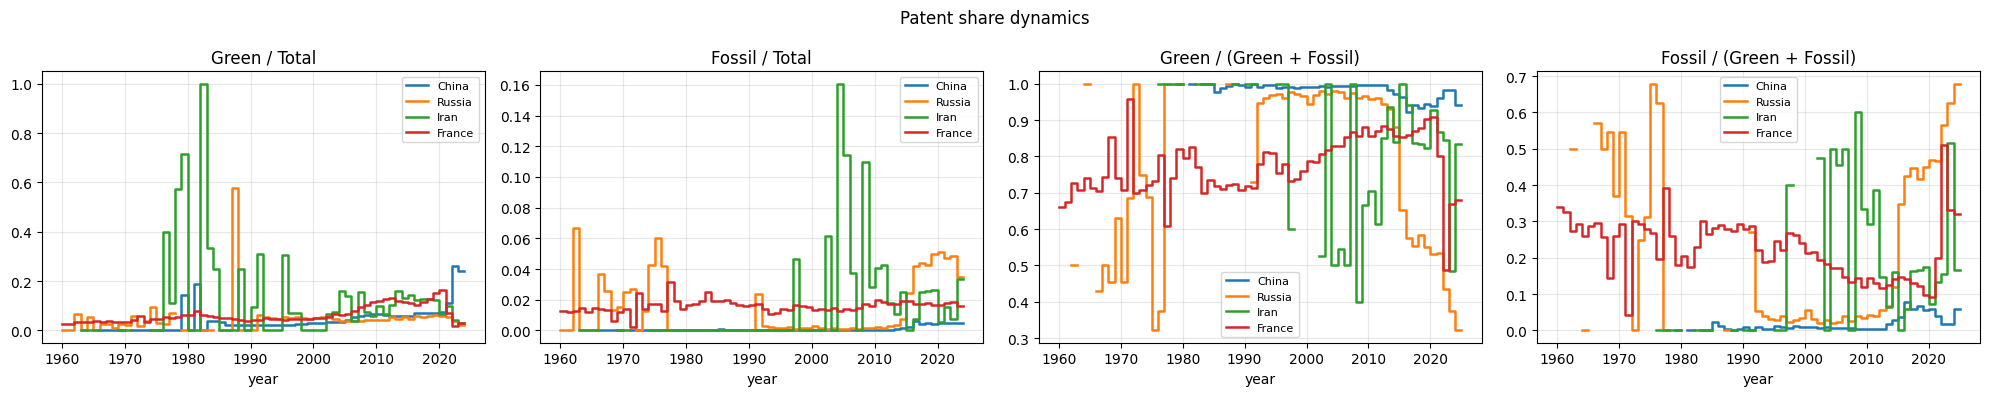

Rows with total_patents > 10: 3,619 / 13,398


,nan_pct,zero_pct,mean,std,min,max
frac_green,0.0%,10.5%,0.0553,0.0483,0.0000,0.5983
frac_fossil,0.0%,30.5%,0.0170,0.0413,0.0000,0.5128
green_of_green_fossil,8.2%,2.3%,0.8127,0.2273,0.0000,1.0000
frac_fossil_of_green_fossil,8.2%,22.4%,0.1873,0.2273,0.0000,1.0000


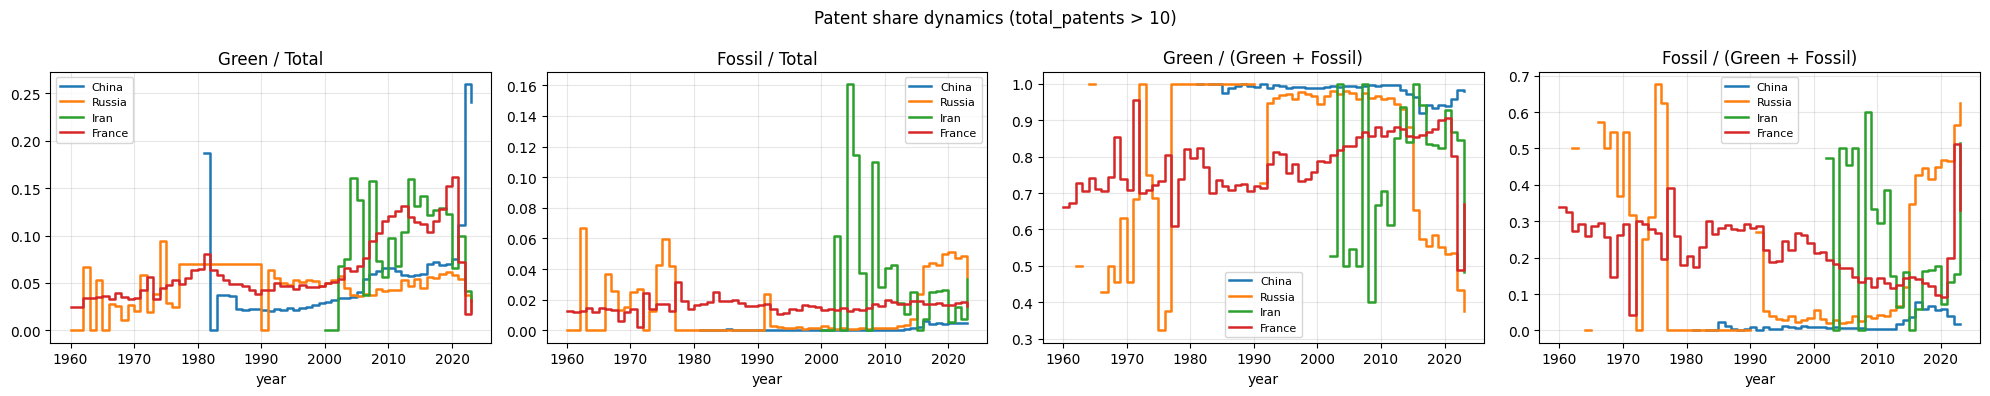

In [114]:
def summarize_fraction_cols(df, cols):

    summary = df[cols].agg([
        lambda s: s.isna().mean() * 100,
        lambda s: (s == 0).mean() * 100,
        'mean', 'std', 'min', 'max',
        ]).T

    summary.columns = ['nan_pct', 'zero_pct', 'mean', 'std', 'min', 'max']

    return (
        summary.style.format({
            'nan_pct': '{:.1f}%', 'zero_pct': '{:.1f}%',
            'mean': '{:.4f}', 'std': '{:.4f}', 'min': '{:.4f}', 'max': '{:.4f}',
            })
        .background_gradient(
            subset=['nan_pct'], cmap='Reds',
            vmin=0, vmax=100,
        )
        .background_gradient(
            subset=['zero_pct'], cmap='Blues',
            vmin=0, vmax=100,
        )
    )


def plot_fraction_series(df, cols, countries, labels=None, title=None):

    fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4))

    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        for iso3, country in countries.items():
            series = (
                df.loc[df['iso3'] == iso3]
                .set_index('year')[col]
                .sort_index().astype(float)
            )
            series.plot(ax=ax, lw=1.8, label=country, drawstyle='steps-post')

        ax.set_title(labels.get(col, col) if labels else col)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        
    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()



vdem = (
    pd.read_csv(processed() / 'vdem.csv')
    [['code', 'year', 'libdem_vdem__estimate_best']]
    .rename(columns={'code': 'iso3'})
    .set_index(['iso3', 'year'])
)

view = panel.assign(
    oil_rents_pct_gdp=final_panel_with_patents_sanctions['oil_rents_pct_gdp'],
    gas_rents_pct_gdp=final_panel_with_patents_sanctions['gas_rents_pct_gdp'],
    )

rent_cols = ['oil_rents_pct_gdp', 'gas_rents_pct_gdp',]

view['oil_gas_rents_pct_gdp'] = (
    view[rent_cols]
    .fillna(0)
    .sum(axis=1)
    .where(view[rent_cols].notna().any(axis=1))
)

view['libdem_vdem'] = vdem['libdem_vdem__estimate_best'].reindex(view.index)

view = view.reset_index()

cols = [
    'iso3', 'year',
    'region_name', 'sub_region_code', 'sub_region_name', 'income_level',
    'total_patents', 'y02_patents', 'fossil_fuel_patents',
    'gdp_pc_current_usd', 'gdp_pc_const_2015_usd', 'trade_pct_gdp', 'fdi_net_inflow_pct_gdp', 'population',
    'oil_gas_rents_pct_gdp', 'libdem_vdem',
    'sanctioned_by_US', 'sanctioned_by_UN', 'sanctioned_by_EU',
    'US_trade', 'EU_trade', 'UN_trade',
    'US_financial', 'EU_financial', 'UN_financial',
    'US_military', 'EU_military', 'UN_military',
    'US_arms', 'EU_arms', 'UN_arms',
    'si_tot_w5', 'si_tot_w10', 'si_tot_w15',
    'si_gdp', 'si_xdis', 'si_mdis',
    'si_dir_tot_trade_normalized', 'si_gdp_nominal',
]

view = (
    view[[c for c in cols if c in view.columns]]
    .sort_values(['iso3', 'year'])
    .reset_index(drop=True)
)


tp = view['total_patents'].replace(0, np.nan)
green = view['y02_patents']
fossil = view['fossil_fuel_patents']

view['frac_green'] = green / tp
view['frac_fossil'] = fossil / tp

gf_total = (
    green.fillna(0)
    + fossil.fillna(0)
).replace(0, np.nan)

valid = green.notna() | fossil.notna()

view['green_of_green_fossil'] = (
    green.fillna(0) / gf_total
).where(valid)

view['frac_fossil_of_green_fossil'] = (
    fossil.fillna(0) / gf_total
).where(valid)


export_path = processed() / 'analysis_panel.csv'

view.to_csv(export_path, index=False)

print(f'{view.shape[0]:,} rows × {view.shape[1]} columns')
print(f'Exported → {export_path}')

countries = {'CHN': 'China', 'RUS': 'Russia', 'IRN': 'Iran', 'FRA': 'France'}

plot_labels = {
    'frac_green': 'Green / Total',
    'frac_fossil': 'Fossil / Total',
    'green_of_green_fossil': 'Green / (Green + Fossil)',
    'frac_fossil_of_green_fossil': 'Fossil / (Green + Fossil)',
}


# Full sample
display(
    summarize_fraction_cols(view, plot_labels.keys())
)

plot_fraction_series(
    df=view,
    cols=plot_labels.keys(),
    countries=countries,
    labels=plot_labels,
    title='Patent share dynamics',
)


# total_patents > 10
view_10 = view.loc[
    view['total_patents'] > 10
].copy()

print(
    f'Rows with total_patents > 10: '
    f'{len(view_10):,} / {len(view):,}'
)

display(
    summarize_fraction_cols(view_10, plot_labels.keys())
)

plot_fraction_series(
    df=view_10,
    cols=plot_labels.keys(),
    countries=countries,
    labels=plot_labels,
    title='Patent share dynamics (total_patents > 10)',
)

In [115]:
def summary_stats_table(
    df,
    cols,
    labels=None,
    caption='Summary Statistics',
    latex_path=None,
):

    cols = [c for c in cols if c in df.columns]

    stats = (
        df[cols]
        .describe(percentiles=[0.25, 0.5, 0.75])
        .T
        .rename(columns={
            'count': 'N',
            'mean': 'Mean',
            'std': 'Std. Dev.',
            'min': 'Min',
            '25%': 'p25',
            '50%': 'Median',
            '75%': 'p75',
            'max': 'Max',
        })
        [['N', 'Mean', 'Std. Dev.', 'Min', 'p25', 'Median', 'p75', 'Max']]
    )

    stats['N'] = stats['N'].astype(int)
    stats['Skewness'] = df[cols].skew()

    if labels:
        stats.index = [labels.get(c, c) for c in stats.index]

    fmt = {
        'N': '{:,}',
        'Mean': '{:,.4f}',
        'Std. Dev.': '{:,.4f}',
        'Min': '{:,.4f}',
        'p25': '{:,.4f}',
        'Median': '{:,.4f}',
        'p75': '{:,.4f}',
        'Max': '{:,.4f}',
        'Skewness': '{:,.2f}',
    }

    styled = (
        stats.style
        .format(fmt)
        .set_caption(caption)
        .set_table_styles([
            {
                'selector': 'caption',
                'props': [
                    ('font-size', '14px'),
                    ('font-weight', 'bold'),
                ],
            }
        ])
    )

    if latex_path:

        latex_df = stats.copy()

        for col, f in fmt.items():
            latex_df[col] = latex_df[col].map(f.format)

        latex = latex_df.to_latex(
            caption=caption,
            label='tab:summary_stats',
            column_format='l' + 'r' * len(latex_df.columns),
            escape=False,
        )

        with open(latex_path, 'w') as f:
            f.write(latex)

        print(f'LaTeX exported → {latex_path}')

    return styled


stat_cols = [
    'si_dir_tot_trade_normalized',
    'gdp_pc_const_2015_usd',
    'trade_pct_gdp',
    'fdi_net_inflow_pct_gdp',
    'population',
    'libdem_vdem',
]

labels = {
    'si_dir_tot_trade_normalized': 'SI: Combined Dir. Total-Trade Norm.',
    'gdp_pc_const_2015_usd': 'GDP per capita (const. 2015 USD)',
    'trade_pct_gdp': 'Trade (% GDP)',
    'fdi_net_inflow_pct_gdp': 'FDI net inflows (% GDP)',
    'population': 'Population',
    'libdem_vdem': 'Liberal Democracy Index (V-Dem)',
}

display(
    summary_stats_table(
        df=view,
        cols=stat_cols,
        labels=labels,
        latex_path=processed() / 'summary_stats.tex',
    )
)

LaTeX exported → /Users/jayranenobari/sanctions_innovations/data/processed/summary_stats.tex


,N,Mean,Std. Dev.,Min,p25,Median,p75,Max,Skewness
SI: Combined Dir. Total-Trade Norm.,"13,398",0.0117,0.0621,0.0000,0.0000,0.0000,0.0000,0.9929,7.34
GDP per capita (const. 2015 USD),"10,934","12,423.3515","19,631.4898",122.6789,"1,349.2670","3,995.1981","15,459.5318","247,170.2199",3.18
Trade (% GDP),"8,470",77.3565,51.5497,0.0210,44.1278,65.9193,96.2505,442.6200,2.44
FDI net inflows (% GDP),"9,224",5.3979,44.3266,"-1,303.1083",0.3119,1.5248,3.9884,"1,709.8272",15.48
Population,"13,195","26,919,503.9415","108,937,056.0965","2,715.0000","645,512.5000","4,790,700.0000","15,739,318.0000","1,450,935,791.0000",9.47
Liberal Democracy Index (V-Dem),"11,046",0.3160,0.2737,0.0050,0.0840,0.2050,0.5368,0.8960,0.69
